In [1]:
import numpy as np
import bayesflow as bf
import sys
sys.path.append("../")
from src.generative_models import *
from src.priors import *

/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
NUM_VAL_SIM = 1000
NUM_SAMPLES = 2000

In [3]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=3,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

## PT Model

In [4]:
pt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

pt_trainer = bf.trainers.Trainer(
    generative_model=pt_model, 
    amortizer=pt_amortizer, 
    configurator=pt_configurator, 
    checkpoint_path=f"../checkpoints/new_approach/{pt_model.name}",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/new_approach/pt_model/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/new_approach/pt_model/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [5]:
val_data = pt_model(NUM_VAL_SIM)
test_data = pt_configurator(val_data)
true_params = val_data['prior_draws']

In [6]:
post_samples_z = pt_amortizer.sample(test_data, NUM_SAMPLES)

In [7]:
post_samples = post_samples_z * PT_PRIOR_STD + PT_PRIOR_MEAN

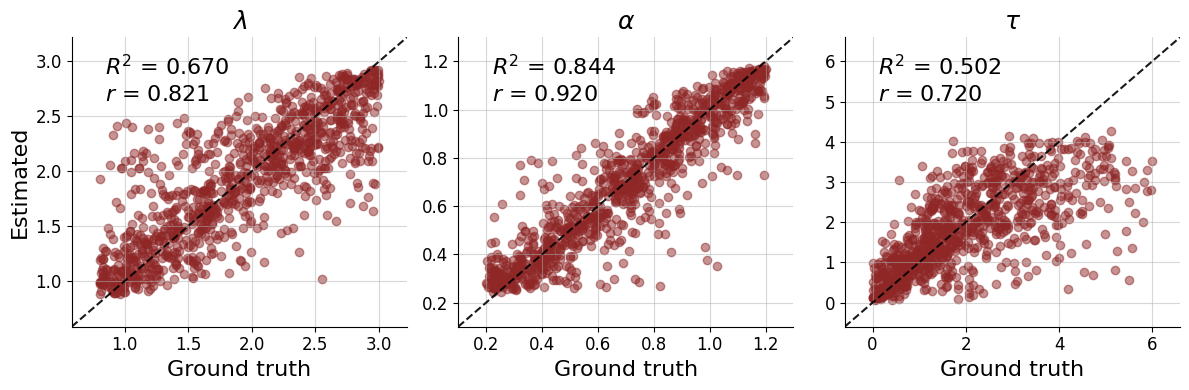

In [8]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=pt_param_names,
    uncertainty_agg=None
)

In [9]:
f.savefig(
    f"../plots/new_approach/{pt_model.name}_recovery.pdf",
    bbox_inches='tight',
    transparent=True,
    dpi=600
)

## CPT Model

In [12]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=4,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [13]:
cpt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

cpt_trainer = bf.trainers.Trainer(
    generative_model=cpt_model, 
    amortizer=cpt_amortizer, 
    configurator=cpt_configurator, 
    checkpoint_path=f"../checkpoints/new_approach/{cpt_model.name}",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/new_approach/cpt_model/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/new_approach/cpt_model/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [14]:
val_data = cpt_model(NUM_VAL_SIM)
test_data = cpt_configurator(val_data)
true_params = val_data['prior_draws']

In [15]:
post_samples_z = cpt_amortizer.sample(test_data, NUM_SAMPLES)

In [16]:
post_samples = post_samples_z * CPT_PRIOR_STD + CPT_PRIOR_MEAN

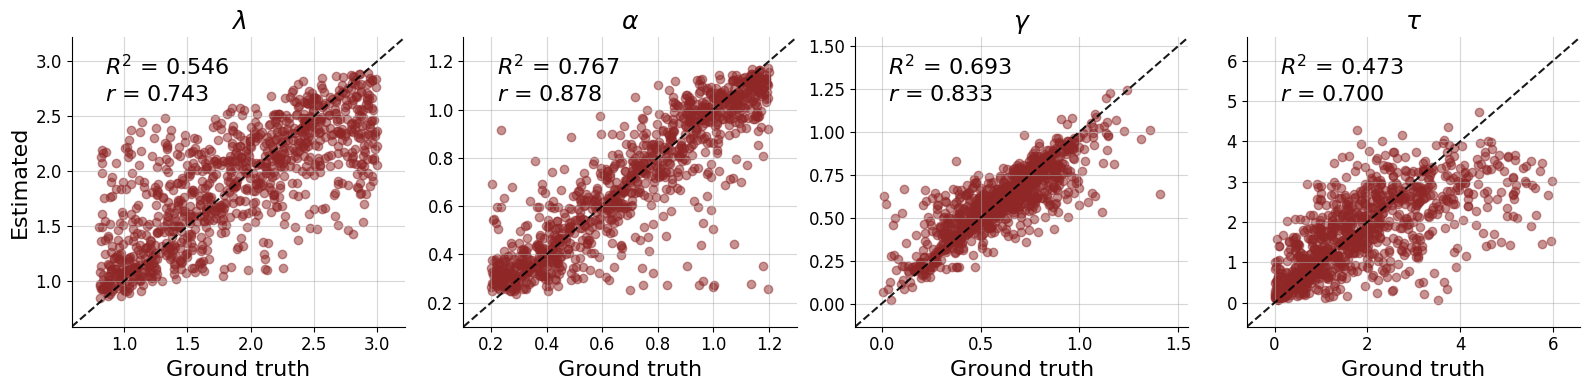

In [17]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=cpt_param_names,
    uncertainty_agg=None
)

In [18]:
f.savefig(
    f"../plots/new_approach/{cpt_model.name}_recovery.pdf",
    bbox_inches='tight',
    transparent=True,
    dpi=600
)

## MVL Model

In [20]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=3,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [21]:
mvl_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

mvl_trainer = bf.trainers.Trainer(
    generative_model=mvl_model, 
    amortizer=mvl_amortizer, 
    configurator=mvl_configurator, 
    checkpoint_path=f"../checkpoints/new_approach/{mvl_model.name}",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/new_approach/mvl_model/history_84.pkl.
INFO:root:Networks loaded from ../checkpoints/new_approach/mvl_model/ckpt-84
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [22]:
val_data = mvl_model(NUM_VAL_SIM)
test_data = mvl_configurator(val_data)
true_params = val_data['prior_draws']

In [23]:
post_samples_z = mvl_amortizer.sample(test_data, NUM_SAMPLES)

In [24]:
post_samples = post_samples_z * MVL_PRIOR_STD + MVL_PRIOR_MEAN

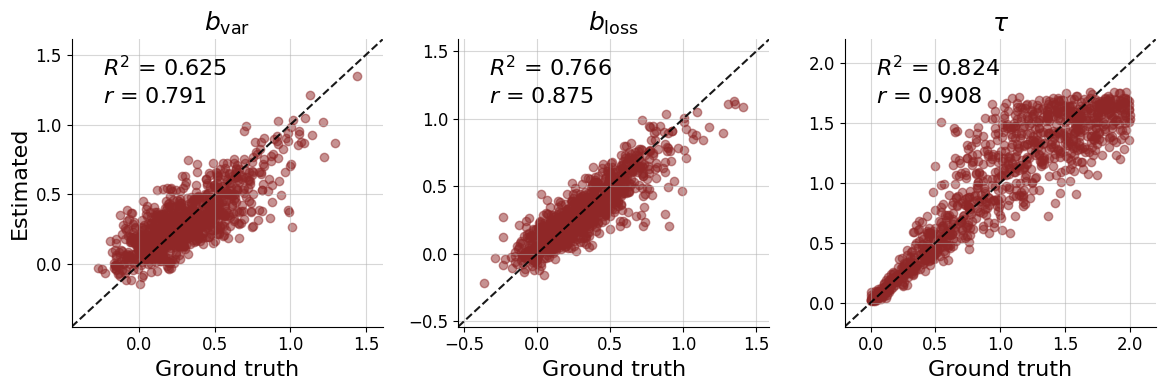

In [25]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=mvl_param_names,
    uncertainty_agg=None
)

In [26]:
f.savefig(
    f"../plots/new_approach/{mvl_model.name}_recovery.pdf",
    bbox_inches='tight',
    transparent=True,
    dpi=600
)